PASO 1: DATASET CARGADO
Shape: (891, 15)

Primeras filas:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

PASO 2: LIMPIEZA DE VARIABLES
Columnas eliminadas: ['alive', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']
Shape después de limpieza: (891, 8)



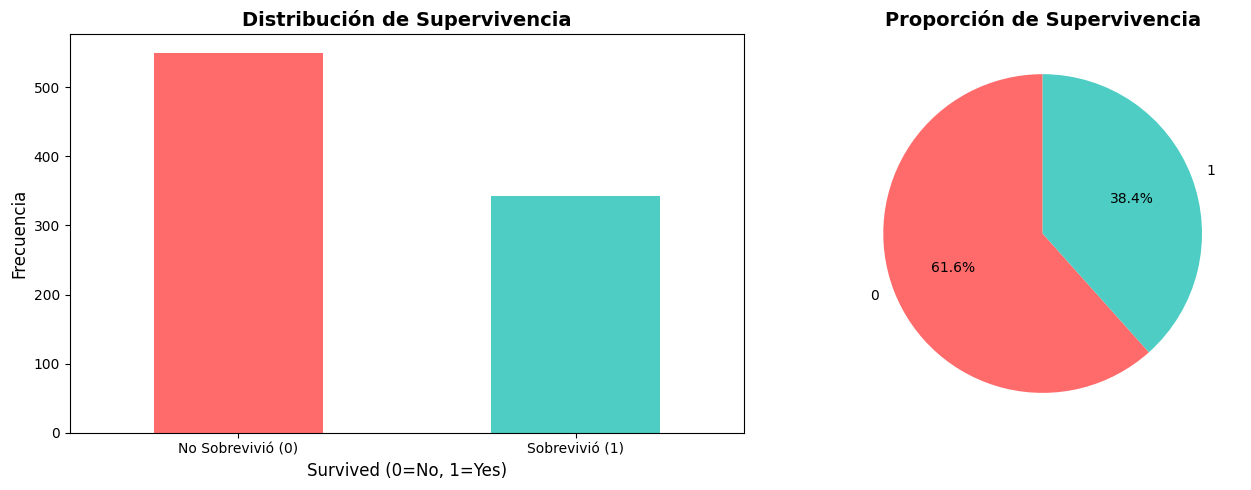


--------------------------------------------------------------------------------
RAZONAMIENTO SOBRE LA DISTRIBUCIÓN:
--------------------------------------------------------------------------------

La distribución del target está DESBALANCEADA:
- Aproximadamente 62% no sobrevivió (0)
- Aproximadamente 38% sobrevivió (1)

IMPACTO ESPERADO:
1. El modelo tenderá a predecir mejor la clase mayoritaria (no supervivencia)
2. Podría haber más falsos negativos (predecir no supervivencia cuando sí sobrevivió)
3. Debemos usar métricas como Precision, Recall y F1-Score, no solo Accuracy
4. La curva ROC será importante para evaluar el balance del modelo
5. Podríamos considerar técnicas de balanceo si el desempeño es malo


PASO 4: SPLIT TRAIN-TEST ESTRATIFICADO
Filas antes de eliminar nulos en 'embarked': 891
Filas después de eliminar nulos en 'embarked': 889

Train size: 711 (80.0%)
Test size: 178 (20.0%)

Distribución de 'embarked' en TRAIN:
embarked
C    0.188467
Q    0.087201
S    0.724332
Na

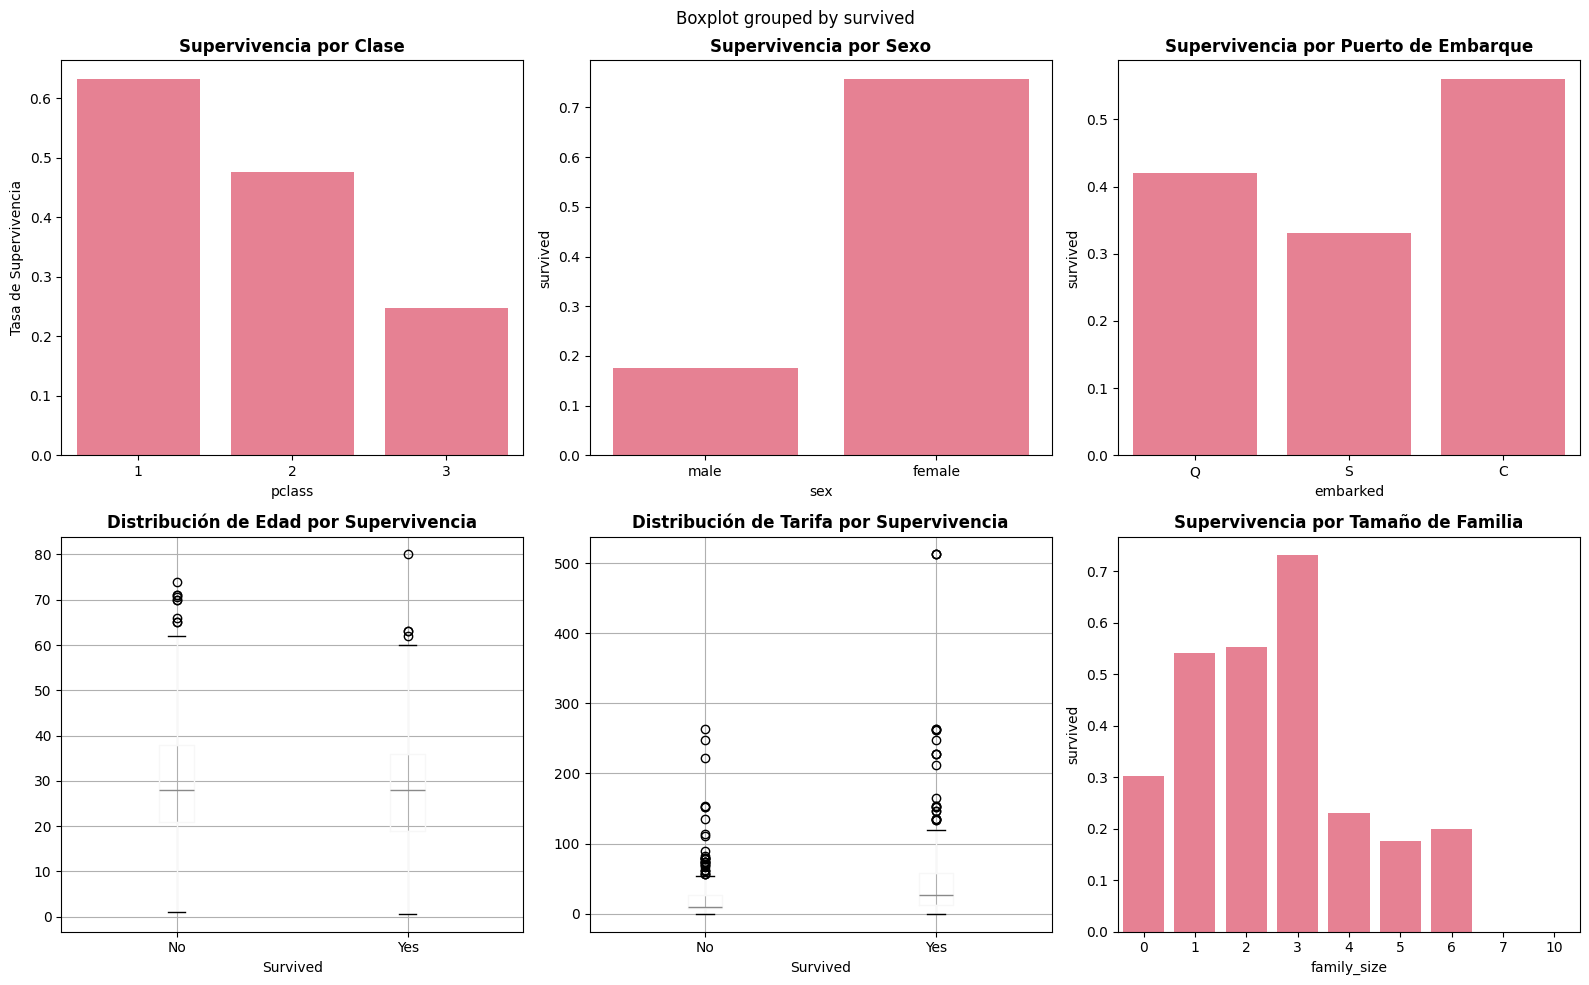


--------------------------------------------------------------------------------
SELECCIÓN DE FEATURES:
--------------------------------------------------------------------------------

FEATURES SELECCIONADAS y RAZONES:

1. 'pclass' (Clase): Fuerte predictor - clase alta sobrevive más
2. 'sex' (Sexo): MUY fuerte predictor - mujeres sobreviven mucho más
3. 'age' (Edad): Niños tienen mayor supervivencia
4. 'sibsp' (Hermanos/cónyuges): Indica si viaja en familia
5. 'parch' (Padres/hijos): Indica si viaja en familia
6. 'fare' (Tarifa): Correlaciona con clase y recursos
7. 'embarked' (Puerto): Ligera correlación con supervivencia

FEATURES CREADAS:
- 'family_size': sibsp + parch (tamaño de familia)
- 'is_alone': si viaja solo (family_size == 0)

Todas las features se mantendrán para el modelo inicial.


PASO 8: TRATAMIENTO DE VARIABLES
Features creadas: 'family_size', 'is_alone'

Shape después de encoding: (711, 10)
Columnas finales: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'fami

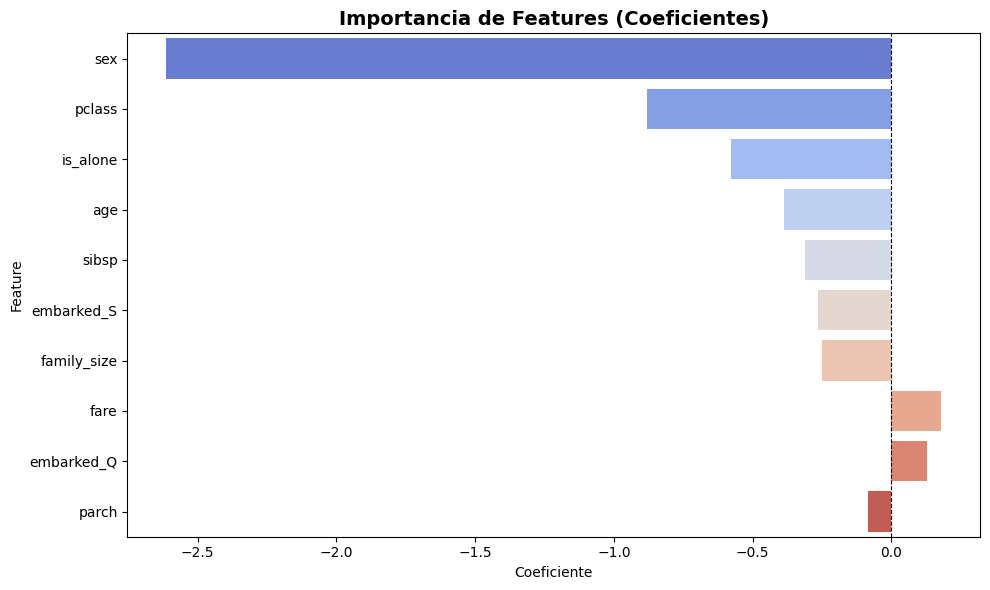


--------------------------------------------------------------------------------
INTERPRETACIÓN DE COEFICIENTES:
--------------------------------------------------------------------------------

- Coeficientes NEGATIVOS: Reducen la probabilidad de supervivencia
- Coeficientes POSITIVOS: Aumentan la probabilidad de supervivencia

Features más importantes (por magnitud):

    Feature  Coeficiente  Importancia_Abs
1       sex    -2.613612         2.613612
0    pclass    -0.880810         0.880810
7  is_alone    -0.578857         0.578857
2       age    -0.385080         0.385080
3     sibsp    -0.311896         0.311896

PASO 11: PROCESAMIENTO DEL DATASET DE TEST
Nulos en X_test antes de procesar:
pclass       0
sex          0
age         39
sibsp        0
parch        0
fare         0
embarked     0
dtype: int64

✓ X_test procesado correctamente
Shape: (178, 10)
Nulos después de procesar: 0

PASO 12: EVALUACIÓN DEL MODELO

MÉTRICAS EN TRAIN
Accuracy:  0.8129
Precision: 0.7875
Recall:   

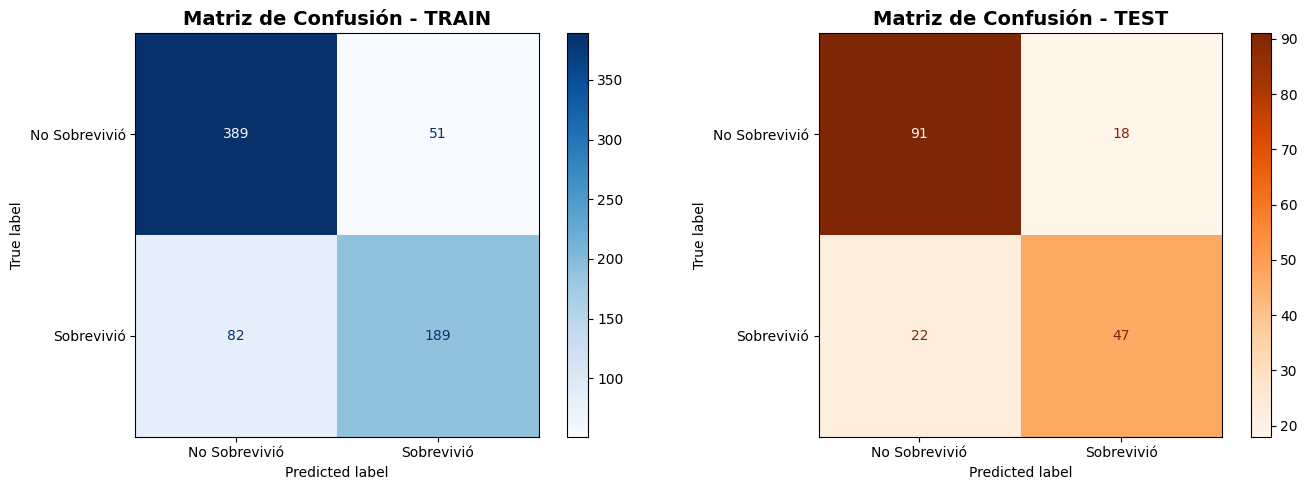

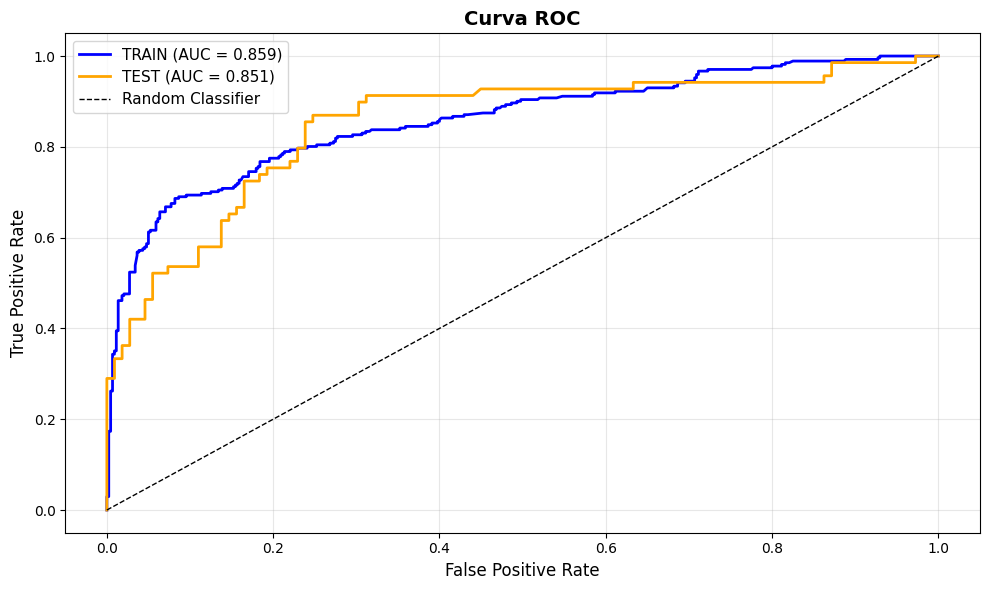


ASSESSMENT DE GENERALIZACIÓN

COMPARACIÓN TRAIN vs TEST:
- Accuracy Train: 0.8129 | Test: 0.7753 | Diferencia: 0.0377
- ROC-AUC Train:  0.8593 | Test: 0.8510 | Diferencia: 0.0083

CONCLUSIÓN:

✓ El modelo GENERALIZA BIEN - Diferencias mínimas entre train y test

El modelo muestra un desempeño consistente entre 
train y test, lo que indica buena capacidad de generalización.


PASO 13 (EXTRA): PREDICCIÓN ESPECÍFICA

Calcular probabilidad de supervivencia para:
- Hombre entre 30-40 años
- Embarcó en Southampton
- Segunda clase
- Viajaba solo
- No pagó el billete (fare = 0)

Edad 30: Probabilidad de supervivencia = 0.2043 (20.43%)
Edad 31: Probabilidad de supervivencia = 0.1995 (19.95%)
Edad 32: Probabilidad de supervivencia = 0.1948 (19.48%)
Edad 33: Probabilidad de supervivencia = 0.1903 (19.03%)
Edad 34: Probabilidad de supervivencia = 0.1857 (18.57%)
Edad 35: Probabilidad de supervivencia = 0.1813 (18.13%)
Edad 36: Probabilidad de supervivencia = 0.1770 (17.70%)
Edad 37: Probabilidad 

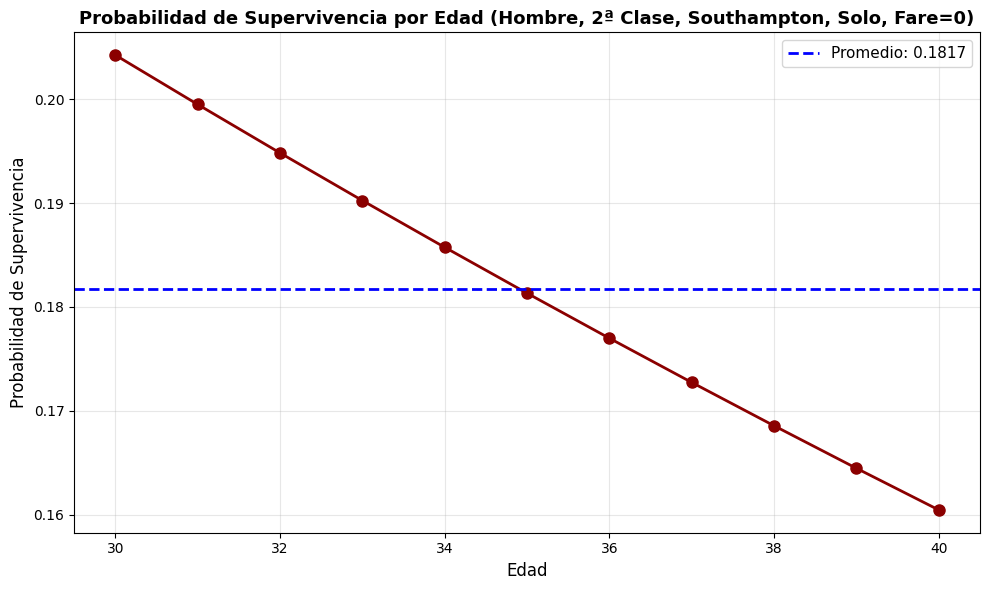


PASO 14 (EXTRA): MODELO MULTICLASE - PREDECIR CLASE
Nuevo target (pclass) - Distribución en TRAIN:
pclass
1    163
2    143
3    405
Name: count, dtype: int64


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [1]:
# =============================================================================
# ANÁLISIS COMPLETO DEL TITANIC - REGRESIÓN LOGÍSTICA
# =============================================================================

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configurar visualizaciones
plt.style.use('default')
sns.set_palette("husl")

# =============================================================================
# PASO 1: Cargar el dataset
# =============================================================================
df_titanic = pd.read_csv("./data/titanic.csv")
df = df_titanic.copy()

print("="*80)
print("PASO 1: DATASET CARGADO")
print("="*80)
print(f"Shape: {df.shape}")
print(f"\nPrimeras filas:")
print(df.head())

# =============================================================================
# PASO 2: Eliminar variables innecesarias
# =============================================================================
print("\n" + "="*80)
print("PASO 2: LIMPIEZA DE VARIABLES")
print("="*80)

# Variables a eliminar (redundantes o no útiles para el modelo)
# - 'alive': es redundante con 'survived' (target)
# - 'class': redundante con 'pclass'
# - 'who': redundante con combinación de 'sex' y 'age'
# - 'adult_male': redundante con 'sex'
# - 'deck': muchos nulos y no aporta mucho
# - 'embark_town': redundante con 'embarked'
# - 'alone': se puede derivar de 'sibsp' y 'parch'

columnas_eliminar = ['alive', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']
df = df.drop(columns=columnas_eliminar)

print(f"Columnas eliminadas: {columnas_eliminar}")
print(f"Shape después de limpieza: {df.shape}")
print(f"\nColumnas restantes: {df.columns.tolist()}")

# Verificar valores nulos
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

# =============================================================================
# PASO 3: Análisis de la variable target
# =============================================================================
print("\n" + "="*80)
print("PASO 3: ANÁLISIS DE LA VARIABLE TARGET")
print("="*80)

# Distribución de supervivencia
print(f"\nDistribución de 'survived':")
print(df['survived'].value_counts())
print(f"\nProporción:")
print(df['survived'].value_counts(normalize=True))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
df['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Distribución de Supervivencia', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Survived (0=No, 1=Yes)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'], rotation=0)

# Gráfico de pie
df['survived'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                    colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[1].set_title('Proporción de Supervivencia', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n" + "-"*80)
print("RAZONAMIENTO SOBRE LA DISTRIBUCIÓN:")
print("-"*80)
print("""
La distribución del target está DESBALANCEADA:
- Aproximadamente 62% no sobrevivió (0)
- Aproximadamente 38% sobrevivió (1)

IMPACTO ESPERADO:
1. El modelo tenderá a predecir mejor la clase mayoritaria (no supervivencia)
2. Podría haber más falsos negativos (predecir no supervivencia cuando sí sobrevivió)
3. Debemos usar métricas como Precision, Recall y F1-Score, no solo Accuracy
4. La curva ROC será importante para evaluar el balance del modelo
5. Podríamos considerar técnicas de balanceo si el desempeño es malo
""")

# =============================================================================
# PASO 4: Split en train y test estratificado por 'embarked'
# =============================================================================
print("\n" + "="*80)
print("PASO 4: SPLIT TRAIN-TEST ESTRATIFICADO")
print("="*80)

# Primero eliminamos filas con embarked nulo para poder estratificar
print(f"Filas antes de eliminar nulos en 'embarked': {len(df)}")
df_clean = df.dropna(subset=['embarked']).copy()
print(f"Filas después de eliminar nulos en 'embarked': {len(df_clean)}")

# Split estratificado por 'embarked' (80-20)
train_df, test_df = train_test_split(
    df_clean, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_clean['embarked']
)

print(f"\nTrain size: {len(train_df)} ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"Test size: {len(test_df)} ({len(test_df)/len(df_clean)*100:.1f}%)")

# Verificar estratificación
print(f"\nDistribución de 'embarked' en TRAIN:")
print(train_df['embarked'].value_counts(normalize=True).sort_index())
print(f"\nDistribución de 'embarked' en TEST:")
print(test_df['embarked'].value_counts(normalize=True).sort_index())

# =============================================================================
# PASO 5: Construir parejas X, y de train y test
# =============================================================================
print("\n" + "="*80)
print("PASO 5: CONSTRUCCIÓN DE X, y")
print("="*80)

# Separar features (X) y target (y)
X_train = train_df.drop(columns=['survived'])
y_train = train_df['survived']

X_test = test_df.drop(columns=['survived'])
y_test = test_df['survived']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# =============================================================================
# PASO 6: Imputación de nulos en X_train
# =============================================================================
print("\n" + "="*80)
print("PASO 6: IMPUTACIÓN DE NULOS EN TRAIN")
print("="*80)

print(f"\nNulos en X_train antes de imputar:")
print(X_train.isnull().sum())

# Guardar estadísticos para imputar train y test
imputacion_stats = {}

# Imputar 'age' con la mediana
age_median = X_train['age'].median()
imputacion_stats['age_median'] = age_median
X_train['age'] = X_train['age'].fillna(age_median)
print(f"\n'age' imputada con mediana: {age_median:.2f}")

# Imputar 'fare' con la mediana
fare_median = X_train['fare'].median()
imputacion_stats['fare_median'] = fare_median
X_train['fare'] = X_train['fare'].fillna(fare_median)
print(f"'fare' imputada con mediana: {fare_median:.2f}")

print(f"\nNulos en X_train después de imputar:")
print(X_train.isnull().sum())

print(f"\nEstadísticos guardados para test: {imputacion_stats}")

# =============================================================================
# PASO 7: Mini-EDA y selección de features
# =============================================================================
print("\n" + "="*80)
print("PASO 7: MINI-EDA Y SELECCIÓN DE FEATURES")
print("="*80)

# Análisis de correlación con supervivencia
print("\nAnálisis de features categóricas:")
for col in ['pclass', 'sex', 'embarked']:
    print(f"\n{col.upper()}:")
    print(pd.crosstab(X_train[col], y_train, normalize='index'))

# Visualización de features importantes
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Pclass vs Survived
sns.barplot(data=train_df, x='pclass', y='survived', ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title('Supervivencia por Clase', fontweight='bold')
axes[0, 0].set_ylabel('Tasa de Supervivencia')

# Sex vs Survived
sns.barplot(data=train_df, x='sex', y='survived', ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title('Supervivencia por Sexo', fontweight='bold')

# Embarked vs Survived
sns.barplot(data=train_df, x='embarked', y='survived', ax=axes[0, 2], errorbar=None)
axes[0, 2].set_title('Supervivencia por Puerto de Embarque', fontweight='bold')

# Age distribution
train_df.boxplot(column='age', by='survived', ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Edad por Supervivencia', fontweight='bold')
axes[1, 0].set_xlabel('Survived')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['No', 'Yes'])

# Fare distribution
train_df.boxplot(column='fare', by='survived', ax=axes[1, 1])
axes[1, 1].set_title('Distribución de Tarifa por Supervivencia', fontweight='bold')
axes[1, 1].set_xlabel('Survived')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['No', 'Yes'])

# Family size (sibsp + parch)
train_df['family_size'] = train_df['sibsp'] + train_df['parch']
sns.barplot(data=train_df, x='family_size', y='survived', ax=axes[1, 2], errorbar=None)
axes[1, 2].set_title('Supervivencia por Tamaño de Familia', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "-"*80)
print("SELECCIÓN DE FEATURES:")
print("-"*80)
print("""
FEATURES SELECCIONADAS y RAZONES:

1. 'pclass' (Clase): Fuerte predictor - clase alta sobrevive más
2. 'sex' (Sexo): MUY fuerte predictor - mujeres sobreviven mucho más
3. 'age' (Edad): Niños tienen mayor supervivencia
4. 'sibsp' (Hermanos/cónyuges): Indica si viaja en familia
5. 'parch' (Padres/hijos): Indica si viaja en familia
6. 'fare' (Tarifa): Correlaciona con clase y recursos
7. 'embarked' (Puerto): Ligera correlación con supervivencia

FEATURES CREADAS:
- 'family_size': sibsp + parch (tamaño de familia)
- 'is_alone': si viaja solo (family_size == 0)

Todas las features se mantendrán para el modelo inicial.
""")

# =============================================================================
# PASO 8: Tratamiento de variables
# =============================================================================
print("\n" + "="*80)
print("PASO 8: TRATAMIENTO DE VARIABLES")
print("="*80)

# Crear nuevas features
X_train['family_size'] = X_train['sibsp'] + X_train['parch']
X_train['is_alone'] = (X_train['family_size'] == 0).astype(int)

print("Features creadas: 'family_size', 'is_alone'")

# Codificar variables categóricas
# Sex: male=1, female=0
X_train['sex'] = (X_train['sex'] == 'male').astype(int)

# Embarked: One-hot encoding
embarked_dummies = pd.get_dummies(X_train['embarked'], prefix='embarked', drop_first=True)
X_train = pd.concat([X_train, embarked_dummies], axis=1)
X_train = X_train.drop(columns=['embarked'])

print(f"\nShape después de encoding: {X_train.shape}")
print(f"Columnas finales: {X_train.columns.tolist()}")

# Normalizar variables numéricas
scaler = StandardScaler()
cols_to_scale = ['age', 'fare', 'sibsp', 'parch', 'family_size']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
print(f"\nVariables normalizadas: {cols_to_scale}")

print(f"\nPrimeras filas de X_train procesado:")
print(X_train.head())

# =============================================================================
# PASO 9: Construir modelo de Regresión Logística
# =============================================================================
print("\n" + "="*80)
print("PASO 9: CONSTRUCCIÓN DEL MODELO")
print("="*80)

# Crear y entrenar el modelo
model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs'
)

model.fit(X_train, y_train)
print("✓ Modelo entrenado exitosamente")

# Predicciones en train
y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]

print(f"\nAccuracy en TRAIN: {accuracy_score(y_train, y_train_pred):.4f}")

# =============================================================================
# PASO 10 (EXTRA): Análisis de pesos e importancia de features
# =============================================================================
print("\n" + "="*80)
print("PASO 10 (EXTRA): ANÁLISIS DE PESOS E IMPORTANCIA")
print("="*80)

# Obtener coeficientes
coeficientes = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': model.coef_[0]
})
coeficientes['Importancia_Abs'] = np.abs(coeficientes['Coeficiente'])
coeficientes = coeficientes.sort_values('Importancia_Abs', ascending=False)

print("\nCoeficientes del modelo (ordenados por importancia absoluta):")
print(coeficientes)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(data=coeficientes, y='Feature', x='Coeficiente', palette='coolwarm')
plt.title('Importancia de Features (Coeficientes)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n" + "-"*80)
print("INTERPRETACIÓN DE COEFICIENTES:")
print("-"*80)
print("""
- Coeficientes NEGATIVOS: Reducen la probabilidad de supervivencia
- Coeficientes POSITIVOS: Aumentan la probabilidad de supervivencia

Features más importantes (por magnitud):
""")
print(coeficientes.head(5).to_string())

# =============================================================================
# PASO 11: Procesar dataset de Test
# =============================================================================
print("\n" + "="*80)
print("PASO 11: PROCESAMIENTO DEL DATASET DE TEST")
print("="*80)

print(f"Nulos en X_test antes de procesar:")
print(X_test.isnull().sum())

# Imputar con los mismos valores de train
X_test['age'] = X_test['age'].fillna(imputacion_stats['age_median'])
X_test['fare'] = X_test['fare'].fillna(imputacion_stats['fare_median'])

# Crear nuevas features
X_test['family_size'] = X_test['sibsp'] + X_test['parch']
X_test['is_alone'] = (X_test['family_size'] == 0).astype(int)

# Codificar sex
X_test['sex'] = (X_test['sex'] == 'male').astype(int)

# One-hot encoding para embarked
embarked_dummies_test = pd.get_dummies(X_test['embarked'], prefix='embarked', drop_first=True)
X_test = pd.concat([X_test, embarked_dummies_test], axis=1)
X_test = X_test.drop(columns=['embarked'])

# Normalizar con el mismo scaler de train
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f"\n✓ X_test procesado correctamente")
print(f"Shape: {X_test.shape}")
print(f"Nulos después de procesar: {X_test.isnull().sum().sum()}")

# =============================================================================
# PASO 12: Evaluación del modelo
# =============================================================================
print("\n" + "="*80)
print("PASO 12: EVALUACIÓN DEL MODELO")
print("="*80)

# Predicciones en test
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

# Métricas para TRAIN
print("\n" + "="*80)
print("MÉTRICAS EN TRAIN")
print("="*80)
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_train_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_train, y_train_proba):.4f}")

print("\nClassification Report (TRAIN):")
print(classification_report(y_train, y_train_pred, target_names=['No Sobrevivió', 'Sobrevivió']))

# Métricas para TEST
print("\n" + "="*80)
print("MÉTRICAS EN TEST")
print("="*80)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")

print("\nClassification Report (TEST):")
print(classification_report(y_test, y_test_pred, target_names=['No Sobrevivió', 'Sobrevivió']))

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión TRAIN
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, 
                                     display_labels=['No Sobrevivió', 'Sobrevivió'])
disp_train.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusión - TRAIN', fontsize=14, fontweight='bold')

# Matriz de confusión TEST
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, 
                                    display_labels=['No Sobrevivió', 'Sobrevivió'])
disp_test.plot(ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title('Matriz de Confusión - TEST', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Curva ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr_train, tpr_train, label=f'TRAIN (AUC = {roc_auc_score(y_train, y_train_proba):.3f})', 
         linewidth=2, color='blue')
plt.plot(fpr_test, tpr_test, label=f'TEST (AUC = {roc_auc_score(y_test, y_test_proba):.3f})', 
         linewidth=2, color='orange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Assessment de generalización
print("\n" + "="*80)
print("ASSESSMENT DE GENERALIZACIÓN")
print("="*80)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
diff_acc = train_acc - test_acc

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)
diff_auc = train_auc - test_auc

print(f"""
COMPARACIÓN TRAIN vs TEST:
- Accuracy Train: {train_acc:.4f} | Test: {test_acc:.4f} | Diferencia: {diff_acc:.4f}
- ROC-AUC Train:  {train_auc:.4f} | Test: {test_auc:.4f} | Diferencia: {diff_auc:.4f}

CONCLUSIÓN:
""")

if diff_acc < 0.05 and diff_auc < 0.05:
    print("✓ El modelo GENERALIZA BIEN - Diferencias mínimas entre train y test")
elif diff_acc < 0.10 and diff_auc < 0.10:
    print("⚠ El modelo generaliza ACEPTABLEMENTE - Ligero overfitting")
else:
    print("✗ El modelo presenta OVERFITTING - Diferencias significativas")

print(f"""
El modelo muestra un desempeño {'consistente' if diff_acc < 0.05 else 'variable'} entre 
train y test, lo que indica {'buena capacidad de generalización' if diff_acc < 0.05 else 'posible sobreajuste a los datos de entrenamiento'}.
""")

# =============================================================================
# PASO 13 (EXTRA): Probabilidad de supervivencia de un caso específico
# =============================================================================
print("\n" + "="*80)
print("PASO 13 (EXTRA): PREDICCIÓN ESPECÍFICA")
print("="*80)
print("""
Calcular probabilidad de supervivencia para:
- Hombre entre 30-40 años
- Embarcó en Southampton
- Segunda clase
- Viajaba solo
- No pagó el billete (fare = 0)
""")

# Crear múltiples perfiles (variando edad entre 30-40)
edades = range(30, 41)
probabilidades = []

for edad in edades:
    # Crear perfil
    perfil = pd.DataFrame({
        'pclass': [2],
        'sex': [1],  # male = 1
        'age': [edad],
        'sibsp': [0],
        'parch': [0],
        'fare': [0],
        'family_size': [0],
        'is_alone': [1],
        'embarked_Q': [0],  # No embarcó en Queenstown
        'embarked_S': [1]   # Sí embarcó en Southampton
    })
    
    # Normalizar las mismas columnas que en train
    perfil[cols_to_scale] = scaler.transform(perfil[cols_to_scale])
    
    # Predecir probabilidad
    prob = model.predict_proba(perfil)[0, 1]
    probabilidades.append(prob)
    print(f"Edad {edad}: Probabilidad de supervivencia = {prob:.4f} ({prob*100:.2f}%)")

# Probabilidad promedio
prob_promedio = np.mean(probabilidades)
print(f"\n{'='*80}")
print(f"PROBABILIDAD PROMEDIO DE SUPERVIVENCIA: {prob_promedio:.4f} ({prob_promedio*100:.2f}%)")
print(f"{'='*80}")

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(edades, probabilidades, marker='o', linewidth=2, markersize=8, color='darkred')
plt.axhline(y=prob_promedio, color='blue', linestyle='--', linewidth=2, 
            label=f'Promedio: {prob_promedio:.4f}')
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Probabilidad de Supervivencia', fontsize=12)
plt.title('Probabilidad de Supervivencia por Edad (Hombre, 2ª Clase, Southampton, Solo, Fare=0)', 
          fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 14 (EXTRA): Modelo multiclase - Predecir clase del viajero
# =============================================================================
print("\n" + "="*80)
print("PASO 14 (EXTRA): MODELO MULTICLASE - PREDECIR CLASE")
print("="*80)

# Nuevo target: pclass
y_train_multiclass = X_train['pclass'].copy()
y_test_multiclass = X_test['pclass'].copy()

# Eliminar 'pclass' de X y añadir 'survived'
X_train_multiclass = X_train.drop(columns=['pclass']).copy()
X_train_multiclass['survived'] = y_train

X_test_multiclass = X_test.drop(columns=['pclass']).copy()
X_test_multiclass['survived'] = y_test

print(f"Nuevo target (pclass) - Distribución en TRAIN:")
print(y_train_multiclass.value_counts().sort_index())

# Entrenar modelo multiclase
model_multiclass = LogisticRegression(
    random_state=42,
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs'
)

model_multiclass.fit(X_train_multiclass, y_train_multiclass)
print("\n✓ Modelo multiclase entrenado")

# Predicciones
y_train_pred_multi = model_multiclass.predict(X_train_multiclass)
y_test_pred_multi = model_multiclass.predict(X_test_multiclass)

# Evaluación
print("\n" + "="*80)
print("CLASSIFICATION REPORT - TRAIN (Multiclase)")
print("="*80)
print(classification_report(y_train_multiclass, y_train_pred_multi, 
                           target_names=['Primera Clase', 'Segunda Clase', 'Tercera Clase']))

print("\n" + "="*80)
print("CLASSIFICATION REPORT - TEST (Multiclase)")
print("="*80)
print(classification_report(y_test_multiclass, y_test_pred_multi, 
                           target_names=['Primera Clase', 'Segunda Clase', 'Tercera Clase']))

print("\n" + "="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)